In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
from fastai.vision.all import load_learner


In [ ]:
from mtrain.smallnet.tfms import resize_and_pad_raw, unpad_and_resize_mask
from mtrain.seg.cityscapes import cached_predict, get_mask_with_labels, CityScapesCls
from tqdm import tqdm
from mtrain.smallnet.tile import split_image_into_tiles
from mtrain.seg import mapillary as mapi


def red(string):
    return "\x1b[31m" + string + "\x1b[0m"


def draw_border_inplace(out, thickness=1, value=255):
    h, w = out.shape[:2]

    out[:thickness, :] = value
    out[h - thickness : h, :] = value
    out[:, :thickness] = value
    out[:, w - thickness : w] = value


def predict_unet(img_path, sz, learner, alpha=0.4):
    img_arr = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    arr_and_coord = split_image_into_tiles(img_arr, sz)
    mask_and_coord = [
        (learner.predict(arr)[0].numpy(), (y, x))
        for (arr, (y, x)) in tqdm(arr_and_coord)
    ]
    res = img_arr.copy()
    H, W = res.shape[:2]
    for mask, (y, x) in tqdm(mask_and_coord):
        ny, nx = min(y + sz, H), min(x + sz, W)
        roi = res[y:ny, x:nx]
        mask = mask[: ny - y, : nx - x]
        mask = mask.astype(bool)

        roi[mask] = (
            (1 - alpha) * roi[mask].astype(np.float32) + alpha * np.array([255, 0, 0])
        ).astype(np.uint8)
    return res


def _with_mapillary_negmask(img_path, orig_mask):
    pred = mapi.cached_predict(img_path)
    neg_mask = mapi.get_mask_with_labels(
        pred,
        [
            mapi.Label.ROAD,
            mapi.Label.VEGETATION,
            mapi.Label.BIKE_LANE,
            mapi.Label.SIDEWALK,
            mapi.Label.SAND,
        ],
    )
    return orig_mask & neg_mask


def predict_unet(img_path, sz, learner, alpha=0.4):
    img_arr = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    arr_and_coord = split_image_into_tiles(img_arr, sz)
    mask_and_coord = [
        (learner.predict(arr)[0].numpy(), (y, x))
        for (arr, (y, x)) in tqdm(arr_and_coord)
    ]
    res = img_arr.copy()
    H, W = res.shape[:2]
    for mask, (y, x) in tqdm(mask_and_coord):
        ny, nx = min(y + sz, H), min(x + sz, W)
        roi = res[y:ny, x:nx]
        mask = mask[: ny - y, : nx - x]
        mask = mask.astype(bool)

        roi[mask] = (
            (1 - alpha) * roi[mask].astype(np.float32) + alpha * np.array([255, 0, 0])
        ).astype(np.uint8)
    return res


def predict_unet_with_resizer(
    img_path, tile_size, after_resize_size, learner, alpha=0.4
):
    img_arr = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    arr_and_coord = split_image_into_tiles(img_arr, tile_size)

    mask_and_coord = []
    for arr, pos in arr_and_coord:
        resized, meta = resize_and_pad_raw(arr, after_resize_size)
        mask_and_coord.append((resized, meta, pos))

    mask_and_coord = [
        (learner.predict(arr)[0].numpy(), meta, pos)
        for (arr, meta, pos) in tqdm(mask_and_coord)
    ]

    mask_and_coord = [
        (unpad_and_resize_mask(arr, meta), pos) for (arr, meta, pos) in mask_and_coord
    ]

    H, W = img_arr.shape[:2]
    res = img_arr.copy()
    full_mask = np.zeros((H, W)).astype(bool)
    for mask, (y, x) in tqdm(mask_and_coord):
        ny, nx = min(y + tile_size, H), min(x + tile_size, W)
        mask = mask[: ny - y, : nx - x]
        mask = mask.astype(bool)
        full_mask[y:ny, x:nx] = mask
        draw_border_inplace(res[y:ny, x:nx])

    # cityscapes
    # full_mask = _with_city_scapes_negmask(img_path, full_mask)

    # mapillary
    # full_mask = _with_mapillary_negmask(img_path, full_mask)

    res[full_mask] = (
        (1 - alpha) * res[full_mask].astype(np.float32) + alpha * np.array([255, 0, 0])
    ).astype(np.uint8)
    return res, full_mask

In [6]:
DS = Path("../../datasets")
POS = DS / "positive-samples"

OUT_MAIN = DS / "test-pos-samples"
OUT_MAIN.mkdir(parents=True, exist_ok=True)
IMAGES = list(POS.glob("*.jpg"))

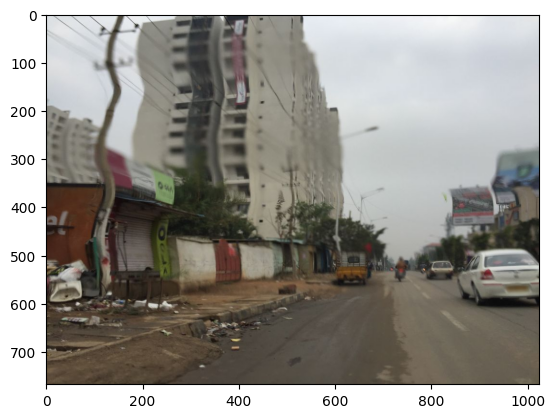

In [7]:
plt.imshow(plt.imread(IMAGES[7]))

In [ ]:
learner = load_learner(
    "/Users/hariomnarang/Desktop/gdrive-sync/garbage/experiments/T008-engulf-v2-only-uncentered/log/export_iter_4.pkl"
)

/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [ ]:
res, _ = predict_unet_with_resizer(IMAGES[7], 50, 50, learner)

100%|██████████| 336/336 [00:00<00:00, 91780.28it/s]


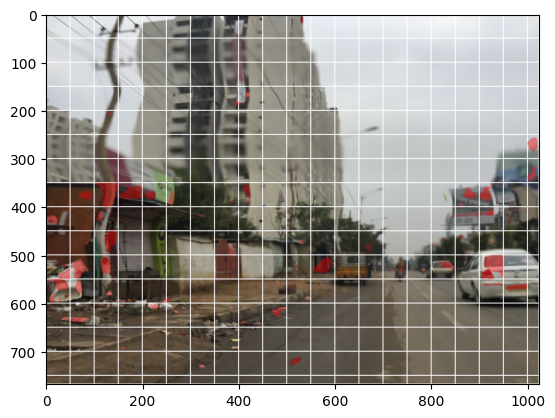

In [13]:
plt.imshow(res)

In [65]:
from PIL import Image

img = plt.imread(IMAGES[7])
images = [
    img[600:650, 450:500],
    img[650:700, 300:350],
    img[600:650, 50:100],
    img[550:600, 100:150],
]
images = [Image.fromarray(image) for image in images]

In [70]:
tdl = learner.dls.test_dl(test_items=images, with_labels=False)

In [71]:
preds, targs = learner.get_preds(dl=tdl)

In [72]:
pred_masks = preds.argmax(dim=1)

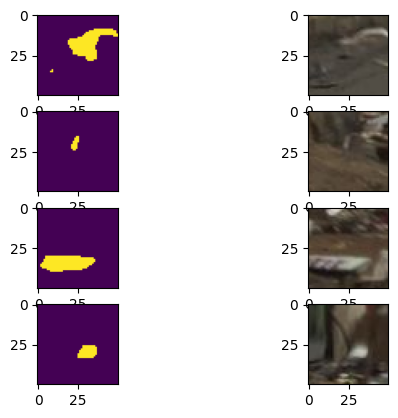

In [74]:
masks = [p for p in pred_masks]

_, ax = plt.subplots(len(pred_masks), 2)
for i in range(len(pred_masks)):
    ax[i][0].imshow(pred_masks[i].numpy())
    ax[i][1].imshow(images[i])

plt.show()

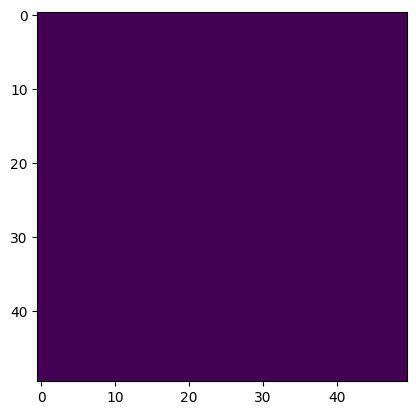

In [31]:
plt.imshow(learner.predict(img[620:670, 360:410])[0])

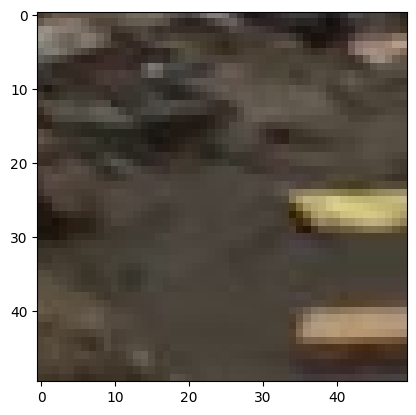

In [14]:
img = plt.imread(IMAGES[7])
plt.imshow(img[650:700, 350:400])

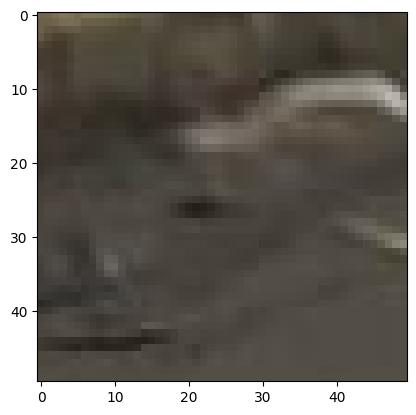

In [ ]:
plt.imshow(img[600:650, 450:500])

In [ ]:
# i also need to somehow do get_preds, single prediction is too slow